In [1]:
import jax 
import jax.numpy as jnp

import jax.linear_util as lu
import jax.api_util as api_util

In [2]:
def log_potential(x, z):
    x_mean = z**2
    return -0.5 * (x_mean - x) ** 2 + -0.5*z**2

log_potential(1, 2)

-6.5

In [3]:
from probjax.inference.mcmc import MCMC
from probjax.inference.mcmc_kernels import UniformKernel, MCMCState, LangevinDynKernel, HMCKernel

mcmc = MCMC(HMCKernel(step_size=0.1, num_steps=10), lambda x: log_potential(4., x), (jax.random.normal(jax.random.PRNGKey(0), (1000,)),))

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
old_state = mcmc.run(jax.random.PRNGKey(0),1000)

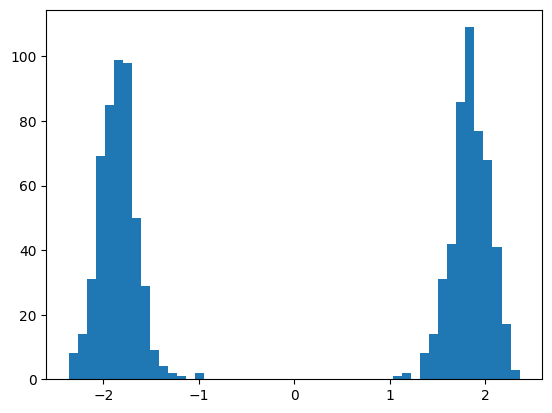

In [5]:
import matplotlib.pyplot as plt

_ = plt.hist(old_state[0], bins=50)

In [6]:
f = lambda x: log_potential(4., x)

x  = jax.random.normal(jax.random.PRNGKey(0), (10,))
potential = f(x)
u = jax.random.uniform(jax.random.PRNGKey(1), (10,))
y = jnp.log(u) + potential


def cond_fn(carry):
    x, potential, y, mask = carry
    return jnp.any(mask)

def body_fn(carry):
    x, potential, y, mask = carry
    x = jax.vmap(jax.lax.cond, in_axes=(0, None, None, 0))(mask, lambda x: x + 0.1, lambda x: x, x)
    #x = jnp.where(mask, x + 0.1, x)
    new_potential = jax.vmap(jax.lax.cond, in_axes=(0, None, None, 0))(mask, f, lambda x: 0., x)
    potential = jnp.where(mask, new_potential, potential)
    mask = potential > y
    return (x, potential, y, mask)

x_upper, _, _, _ = jax.lax.while_loop(cond_fn, body_fn, (x, potential, y, jnp.ones_like(y, dtype=bool)))

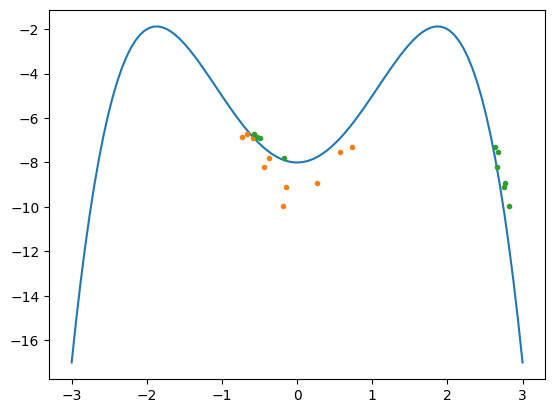

In [8]:
line = jnp.linspace(-3, 3, 100)
plt.plot(line, f(line))
plt.plot(x, y, ".")
plt.plot(x_upper, y, ".")

In [74]:
log_pot1 = log_potential(new_state[0].x, new_state[1].x)
log_pot2 = log_potential(old_state[0].x, old_state[1].x)
log_ratio = jnp.clip(log_pot1 - log_pot2, a_max=0.)
unif = jnp.log(jax.random.uniform(jax.random.PRNGKey(2), shape=log_ratio.shape))

accept = unif < log_ratio


jax.tree_map(lambda new,old: jnp.where(accept, new.x,old.x), new_state, old_state, is_leaf=lambda x: isinstance(x, MCMCState))

[Array([1.4319856 , 0.6668863 , 0.81821495, 2.0833151 , 0.48361403,
        1.8536167 , 1.1654568 , 0.32930887, 0.9959417 , 1.2120253 ],      dtype=float32),
 Array([ 1.2401801 ,  1.1227748 ,  0.6144342 ,  0.48860514, -1.4583249 ,
         0.8504556 , -0.1403552 ,  0.47335973,  0.0024598 ,  1.0073266 ],      dtype=float32)]

In [43]:
def flatten_fun(f, *args):
    
    def flat_fun(*args):
        fun = lu.wrap_init(f)
        flatten_args, in_tree = jax.tree_util.tree_flatten(args)
        jax_tree_fun, out_tree = api_util.flatten_fun_nokwargs(fun, in_tree)  # type: ignore
        out = jax_tree_fun.call_wrapped(*flatten_args)
        return jax.tree_util.tree_unflatten(out_tree(), out)
    
    return flat_fun

In [44]:
f = flatten_fun(log_potential)

In [45]:
f(jnp.ones(1)*2, jnp.ones(1))

TypeError: log_potential() takes 1 positional argument but 2 were given